In [3]:
#@title SETUP

"""
Tie Training — Isotropic Experiments (Extended)
================================================
Validates the mixture, augmentation, and near-tie theory from the
reviewer-requested appendix.

Experiments:
  1. Mixture α-sweep (original): ||θ_s^mix|| / ||θ_s^strict|| vs α
     Theory: r(α) = α·λ₀ / (α·λ₀ + (1-α)·σ²)

  2. Augmentation γ-sweep: ||θ_s^aug|| / ||θ_s^strict|| vs γ = m/n
     Theory: r_aug(γ) = λ₀ / (λ₀ + γ·σ²)

  3. Near-tie tolerance: sweep causal mismatch (η, τ_c², κ) and
     measure deviation from exact-tie baseline

  4. Causal decontamination: verify θ_c^mix as 1-α (ties) increases

Data generation levels:
  - BT_full:  labels from σ(θ*⊤ Δφ), isotropic features
  - BT_causal: labels from σ(θ_c*⊤ Δφ_c), ρ-correlated features
  - no_BT:    Δφ ~ N(μ, Cov), no labels, direct DPO
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from tqdm.auto import tqdm

In [4]:
#@title 1. CONFIG & DEVICE

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


def set_seed(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

Using device: cpu


In [5]:
#@title 2. HELPERS

def split_theta(theta, d_c):
    return theta[:d_c], theta[d_c:]

def orient_data(D_phi, y):
    """
    Convert (features, labels) to DPO-oriented data X = (2y-1) * D_phi.
    """
    if y is not None:
        return (2.0 * y - 1.0) * D_phi
    else:
        return D_phi

In [6]:
#@title 3. SOLVERS

def dpo_grad(theta, X, beta):
    z = beta * (X @ theta)
    w = 1.0 - torch.sigmoid(z)
    return -beta * (X.T @ w) / X.shape[0]

def solve_dpo(X, beta, lr=0.05, steps=20000, tol=1e-10):
    """
    Solve DPO via gradient descent.
    """
    d = X.shape[1]
    theta = torch.zeros(d, dtype=X.dtype, device=X.device)
    for step in range(steps):
        g = dpo_grad(theta, X, beta)
        theta = theta - lr * g
        if torch.linalg.norm(g) < tol:
            break
    return theta

def linear_solution(mu, Sigma, beta):
    """
    Closed-form linearized equilibrium: θ* = (2/β) Σ⁻¹ μ.
    """
    return (2.0 / beta) * torch.linalg.solve(Sigma, mu)

def empirical_moments(D_phi, y=None):
    """
    Compute empirical Σ̂ and μ̂.
    """
    n = D_phi.shape[0]
    Sigma_hat = (D_phi.T @ D_phi) / n
    if y is not None:
        mu_hat = (D_phi.T @ (2.0 * y - 1.0)).squeeze() / n
    else:
        mu_hat = D_phi.mean(dim=0)
    return mu_hat, Sigma_hat

In [7]:
#@title 4. DATA GENERATION — Strict preferences

@torch.no_grad()
def make_strict_BT(n, d_c, d_s, theta_c, theta_s, beta, lam0=1.0):
    """
    BT full teacher with isotropic spurious: Σ_ss = λ₀ I.
    Returns X, y, Xs (spurious block for covariance estimation).
    """
    Xc = torch.randn(n, d_c, device=DEVICE)
    Xs = torch.randn(n, d_s, device=DEVICE) * np.sqrt(lam0)
    X = torch.cat([Xc, Xs], dim=1)
    theta = torch.cat([theta_c, theta_s])
    p = torch.sigmoid(beta * (X @ theta)).unsqueeze(1)
    y = (torch.rand(n, 1, device=DEVICE) < p).float()
    return X, y, Xs

@torch.no_grad()
def make_strict_BT_causal(n, d_c, d_s, theta_c, beta, lam0=1.0, rho=0.0):
    """
    BT causal-only teacher with ρ-correlation and isotropic spurious.
    """
    Xc = torch.randn(n, d_c, device=DEVICE)
    Xs = torch.randn(n, d_s, device=DEVICE) * np.sqrt(lam0)
    # Inject correlation
    min_d = min(d_c, d_s)
    Xs[:, :min_d] = (rho * Xc[:, :min_d] +
                     (1 - rho**2)**0.5 * Xs[:, :min_d])
    X = torch.cat([Xc, Xs], dim=1)
    p = torch.sigmoid(beta * (Xc @ theta_c)).unsqueeze(1)
    y = (torch.rand(n, 1, device=DEVICE) < p).float()
    return X, y, Xs

def make_strict_no_BT(n, d_c, d_s, mu_scale=0.1):
    """
    No BT model: Δφ ~ N(μ, Cov) with well-conditioned covariance.
    Returns D_phi (no labels needed).
    """
    d = d_c + d_s
    mu = mu_scale * (torch.rand(d, device=DEVICE) * 2 - 1)

    # Well-conditioned covariance
    A = torch.randn(d, d, device=DEVICE)
    Cov_raw = A @ A.T
    diag_inv_sqrt = torch.diag(1.0 / torch.sqrt(torch.diag(Cov_raw)))
    corr_matrix = diag_inv_sqrt @ Cov_raw @ diag_inv_sqrt
    Cov = 0.3 * torch.eye(d, device=DEVICE) + 0.7 * corr_matrix

    dist = torch.distributions.MultivariateNormal(mu, Cov)
    D_phi = dist.sample((n,))

    return D_phi, mu, Cov

In [8]:
#@title 5. DATA GENERATION — Ties

@torch.no_grad()
def make_ties_exact(n, d_c, d_s, sig2):
    """
    Exact ties: Δφ_c = 0, Δφ_s ~ N(0, σ² I), y ~ Bernoulli(0.5).
    """
    Xc = torch.zeros(n, d_c, device=DEVICE)
    Xs = torch.randn(n, d_s, device=DEVICE) * np.sqrt(sig2)
    X = torch.cat([Xc, Xs], dim=1)
    y = (torch.rand(n, 1, device=DEVICE) < 0.5).float()
    return X, y

@torch.no_grad()
def make_ties_near(n, d_c, d_s, sig2, eta=0.0, tau_c2=0.0, kappa=0.0):
    """
    Near ties with causal mismatch:
      - η:     causal mean bias (Δφ_c has mean η·1)
      - τ_c²:  causal curvature (Δφ_c ~ N(η·1, τ_c² I))
      - κ:     causal-spurious coupling (added to off-diagonal of cov)

    Spurious block: Δφ_s ~ N(0, σ² I)
    Label: y ~ Bernoulli(0.5) (randomized)
    """
    # Causal block with mismatch
    Xc = torch.randn(n, d_c, device=DEVICE) * np.sqrt(tau_c2)
    Xc = Xc + eta  # add mean bias

    # Spurious block
    Xs = torch.randn(n, d_s, device=DEVICE) * np.sqrt(sig2)

    # Inject causal-spurious coupling κ
    # Simple model: add κ * (shared noise) to both blocks
    if abs(kappa) > 1e-12:
        min_d = min(d_c, d_s)
        shared = torch.randn(n, min_d, device=DEVICE)
        # κ enters as cross-covariance: E[Xc_i Xs_j] = κ for i=j
        Xc[:, :min_d] = Xc[:, :min_d] + kappa * shared
        Xs[:, :min_d] = Xs[:, :min_d] + shared  # already scaled by sig2 above

    X = torch.cat([Xc, Xs], dim=1)
    y = (torch.rand(n, 1, device=DEVICE) < 0.5).float()
    return X, y

def make_ties_no_BT(n, d_c, d_s, sig2):
    """
    Ties for the no_BT setting: Δφ_c = 0, Δφ_s ~ N(0, σ² I).
    No labels — data is used directly as feature differences.
    """
    Xc = torch.zeros(n, d_c, device=DEVICE)
    Xs = torch.randn(n, d_s, device=DEVICE) * np.sqrt(sig2)
    X = torch.cat([Xc, Xs], dim=1)
    return X

In [9]:
#@title 6. MIXING AND SOLVING

def solve_strict(X, y, beta, lr=0.05, steps=20000):
    """
    Solve DPO on strict preference data.
    """
    X_dpo = orient_data(X, y)
    return solve_dpo(X_dpo, beta, lr=lr, steps=steps)

def solve_strict_no_BT(D_phi, beta, lr=0.05, steps=20000):
    """
    Solve DPO on no-BT data (already oriented).
    """
    return solve_dpo(D_phi, beta, lr=lr, steps=steps)

def mix_data_BT(X_strict, y_strict, X_tie, y_tie):
    """
    Concatenate and shuffle strict + tie data.
    """
    X = torch.cat([X_strict, X_tie], dim=0)
    y = torch.cat([y_strict, y_tie], dim=0)
    perm = torch.randperm(X.shape[0], device=DEVICE)
    return X[perm], y[perm]

def mix_data_no_BT(D_phi_strict, D_phi_tie):
    """
    Concatenate and shuffle for no-BT setting.
    """
    D = torch.cat([D_phi_strict, D_phi_tie], dim=0)
    perm = torch.randperm(D.shape[0], device=DEVICE)
    return D[perm]

In [10]:
#@title 7. THEORETICAL PREDICTIONS (isotropic)

def r_mixture(alpha, lam0, sig2):
    """
    Isotropic mixture leakage factor:
    r(α) = α·λ₀ / (α·λ₀ + (1-α)·σ²)
    This is the ratio ||θ_s^mix|| / ||θ_s^strict||.
    """
    denom = alpha * lam0 + (1 - alpha) * sig2
    if denom <= 0:
        return float('nan')
    return alpha * lam0 / denom

def r_augmentation(gamma, lam0, sig2):
    """
    Isotropic augmentation leakage factor:
    r_aug(γ) = λ₀ / (λ₀ + γ·σ²)
    """
    denom = lam0 + gamma * sig2
    if denom <= 0:
        return float('nan')
    return lam0 / denom

def cov_lambda_min_empirical(Xs):
    """
    Smallest eigenvalue of empirical covariance of Xs.
    """
    Xc = Xs - Xs.mean(dim=0, keepdim=True)
    Sigma = (Xc.T @ Xc) / Xc.shape[0]
    eigvals = torch.linalg.eigvalsh(Sigma)
    return float(eigvals.min().item())

In [11]:
#@title 8. EXPERIMENT 1: Mixture α-sweep (original + extended levels)

def experiment_mixture_alpha_sweep(
    level="BT_full",
    N=8000,
    d_c=5,
    d_s=5,
    beta=0.3,
    seeds=30,
    alphas=(0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
    sigma_ratios=(5.0,),
    lam0=1.0,
    theta_scale=1.0,
    mu_scale=0.1,
    rho=0.5,
):
    """
    Mixture model: fixed budget N, split into n_strict = α·N and n_tie = (1-α)·N.
    Measures ||θ_s^mix|| / ||θ_s^strict|| vs α.

    level: "BT_full" | "BT_causal" | "no_BT"
    """
    set_seed(0)
    theta_c = theta_scale * torch.randn(d_c, device=DEVICE)
    theta_s = theta_scale * torch.randn(d_s, device=DEVICE)

    rows = []
    for sr in sigma_ratios:
        sig2 = sr * lam0
        for a in alphas:
            for seed in tqdm(range(seeds), leave=False, desc=f"sr={sr}, α={a}"):
                set_seed(seed)

                n_strict = int(round(a * N))
                n_tie = N - n_strict

                if level == "BT_full":
                    # Strict-only baseline
                    X_base, y_base, Xs_base = make_strict_BT(
                        N, d_c, d_s, theta_c, theta_s, beta, lam0)
                    th_base = solve_strict(X_base, y_base, beta)
                    norm_base = th_base[d_c:].norm().item()
                    lam0_hat = cov_lambda_min_empirical(Xs_base)

                    # Mixed
                    Xs, ys, Xs_s = make_strict_BT(
                        n_strict, d_c, d_s, theta_c, theta_s, beta, lam0)
                    Xt, yt = make_ties_exact(n_tie, d_c, d_s, sig2)
                    Xmix, ymix = mix_data_BT(Xs, ys, Xt, yt)
                    th_mix = solve_strict(Xmix, ymix, beta)
                    norm_mix = th_mix[d_c:].norm().item()
                    sig2_hat = cov_lambda_min_empirical(
                        Xmix[n_strict:, d_c:]) if n_tie >= d_s else float("nan")

                elif level == "BT_causal":
                    X_base, y_base, Xs_base = make_strict_BT_causal(
                        N, d_c, d_s, theta_c, beta, lam0, rho)
                    th_base = solve_strict(X_base, y_base, beta)
                    norm_base = th_base[d_c:].norm().item()
                    lam0_hat = cov_lambda_min_empirical(Xs_base)

                    Xs, ys, Xs_s = make_strict_BT_causal(
                        n_strict, d_c, d_s, theta_c, beta, lam0, rho)
                    Xt, yt = make_ties_exact(n_tie, d_c, d_s, sig2)
                    Xmix, ymix = mix_data_BT(Xs, ys, Xt, yt)
                    th_mix = solve_strict(Xmix, ymix, beta)
                    norm_mix = th_mix[d_c:].norm().item()
                    sig2_hat = cov_lambda_min_empirical(
                        Xmix[n_strict:, d_c:]) if n_tie >= d_s else float("nan")

                elif level == "no_BT":
                    # Strict-only baseline
                    D_phi_base, _, _ = make_strict_no_BT(N, d_c, d_s, mu_scale)
                    th_base = solve_strict_no_BT(D_phi_base, beta)
                    norm_base = th_base[d_c:].norm().item()
                    lam0_hat = cov_lambda_min_empirical(D_phi_base[:, d_c:])

                    # Mixed
                    D_phi_s, _, _ = make_strict_no_BT(n_strict, d_c, d_s, mu_scale)
                    D_phi_t = make_ties_no_BT(n_tie, d_c, d_s, sig2)
                    D_phi_mix = mix_data_no_BT(D_phi_s, D_phi_t)
                    th_mix = solve_strict_no_BT(D_phi_mix, beta)
                    norm_mix = th_mix[d_c:].norm().item()
                    sig2_hat = cov_lambda_min_empirical(
                        D_phi_t[:, d_c:]) if n_tie >= d_s else float("nan")

                r_emp = norm_mix / (norm_base + 1e-12)
                denom = a * lam0_hat + (1 - a) * sig2_hat
                r_th = (a * lam0_hat / denom) if (denom > 0 and np.isfinite(sig2_hat)) else float("nan")

                rows.append({
                    "seed": seed, "alpha": a, "sigma_ratio": sr,
                    "lam0_hat": lam0_hat, "sig2_hat": sig2_hat,
                    "r_emp": r_emp, "r_th": r_th, "level": level,
                    "norm_base": norm_base, "norm_mix": norm_mix,
                })

    return pd.DataFrame(rows)

In [12]:
#@title 9. EXPERIMENT 2: Augmentation γ-sweep

def experiment_augmentation_gamma_sweep(
    level="BT_full",
    n_strict=5000,
    d_c=5,
    d_s=5,
    beta=0.3,
    seeds=30,
    gammas=(0.0, 0.5, 1.0, 2.0, 5.0, 10.0),
    sigma_ratios=(5.0,),
    lam0=1.0,
    theta_scale=1.0,
    mu_scale=0.1,
    rho=0.5,
):
    """
    Augmentation model: fixed n_strict, add m = γ·n_strict ties on top.
    Measures ||θ_s^aug|| / ||θ_s^strict|| vs γ.

    Theory: r_aug(γ) = λ₀ / (λ₀ + γ·σ²)
    """
    set_seed(0)
    theta_c = theta_scale * torch.randn(d_c, device=DEVICE)
    theta_s = theta_scale * torch.randn(d_s, device=DEVICE)

    rows = []
    for sr in sigma_ratios:
        sig2 = sr * lam0
        for gamma in gammas:
            n_tie = int(round(gamma * n_strict))
            for seed in tqdm(range(seeds), leave=False, desc=f"sr={sr}, γ={gamma}"):
                set_seed(seed)

                if level == "BT_full":
                    # Strict-only baseline (same n_strict)
                    X_base, y_base, Xs_base = make_strict_BT(
                        n_strict, d_c, d_s, theta_c, theta_s, beta, lam0)
                    th_base = solve_strict(X_base, y_base, beta)
                    norm_base = th_base[d_c:].norm().item()
                    lam0_hat = cov_lambda_min_empirical(Xs_base)

                    if n_tie > 0:
                        # Augmented: same strict data + extra ties
                        Xt, yt = make_ties_exact(n_tie, d_c, d_s, sig2)
                        Xaug, yaug = mix_data_BT(X_base, y_base, Xt, yt)
                        th_aug = solve_strict(Xaug, yaug, beta)
                        norm_aug = th_aug[d_c:].norm().item()
                        sig2_hat = cov_lambda_min_empirical(Xt[:, d_c:])
                    else:
                        norm_aug = norm_base
                        sig2_hat = sig2

                elif level == "BT_causal":
                    X_base, y_base, Xs_base = make_strict_BT_causal(
                        n_strict, d_c, d_s, theta_c, beta, lam0, rho)
                    th_base = solve_strict(X_base, y_base, beta)
                    norm_base = th_base[d_c:].norm().item()
                    lam0_hat = cov_lambda_min_empirical(Xs_base)

                    if n_tie > 0:
                        Xt, yt = make_ties_exact(n_tie, d_c, d_s, sig2)
                        Xaug, yaug = mix_data_BT(X_base, y_base, Xt, yt)
                        th_aug = solve_strict(Xaug, yaug, beta)
                        norm_aug = th_aug[d_c:].norm().item()
                        sig2_hat = cov_lambda_min_empirical(Xt[:, d_c:])
                    else:
                        norm_aug = norm_base
                        sig2_hat = sig2

                elif level == "no_BT":
                    D_phi_base, _, _ = make_strict_no_BT(n_strict, d_c, d_s, mu_scale)
                    th_base = solve_strict_no_BT(D_phi_base, beta)
                    norm_base = th_base[d_c:].norm().item()
                    lam0_hat = cov_lambda_min_empirical(D_phi_base[:, d_c:])

                    if n_tie > 0:
                        D_phi_t = make_ties_no_BT(n_tie, d_c, d_s, sig2)
                        D_phi_aug = mix_data_no_BT(D_phi_base, D_phi_t)
                        th_aug = solve_strict_no_BT(D_phi_aug, beta)
                        norm_aug = th_aug[d_c:].norm().item()
                        sig2_hat = cov_lambda_min_empirical(D_phi_t[:, d_c:])
                    else:
                        norm_aug = norm_base
                        sig2_hat = sig2

                r_emp = norm_aug / (norm_base + 1e-12)
                r_th = r_augmentation(gamma, lam0_hat, sig2_hat)

                rows.append({
                    "seed": seed, "gamma": gamma, "sigma_ratio": sr,
                    "lam0_hat": lam0_hat, "sig2_hat": sig2_hat,
                    "r_emp": r_emp, "r_th": r_th, "level": level,
                    "norm_base": norm_base, "norm_aug": norm_aug,
                })

    return pd.DataFrame(rows)

In [13]:
#@title 10. EXPERIMENT 3: Near-tie tolerance sweep

def experiment_near_tie_sweep(
    level="BT_full",
    N=8000,
    d_c=5,
    d_s=5,
    beta=0.3,
    seeds=20,
    alpha=0.7,
    sig2=5.0,
    lam0=1.0,
    theta_scale=1.0,
    mu_scale=0.1,
    rho=0.5,
    # Sweep one mismatch at a time; others fixed at 0
    sweep_param="eta",
    sweep_values=None,
):
    """
    Near-tie tolerance: fix α, sweep one of (η, τ_c², κ),
    measure ||θ_c^near - θ_c^exact|| and ||θ_s^near|| / ||θ_s^exact||.

    sweep_param: "eta" | "tau_c2" | "kappa"
    """
    if sweep_values is None:
        if sweep_param == "eta":
            sweep_values = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]
        elif sweep_param == "tau_c2":
            sweep_values = [0.0, 0.01, 0.05, 0.1, 0.5, 1.0]
        elif sweep_param == "kappa":
            sweep_values = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]

    set_seed(0)
    theta_c = theta_scale * torch.randn(d_c, device=DEVICE)
    theta_s = theta_scale * torch.randn(d_s, device=DEVICE)

    n_strict = int(round(alpha * N))
    n_tie = N - n_strict

    rows = []
    for val in sweep_values:
        # Set mismatch parameters
        eta = val if sweep_param == "eta" else 0.0
        tau_c2 = val if sweep_param == "tau_c2" else 0.0
        kappa = val if sweep_param == "kappa" else 0.0

        for seed in tqdm(range(seeds), leave=False, desc=f"{sweep_param}={val}"):
            set_seed(seed)

            if level == "BT_full":
                # Strict data
                Xs, ys, _ = make_strict_BT(
                    n_strict, d_c, d_s, theta_c, theta_s, beta, lam0)

                # Exact-tie baseline
                Xt_exact, yt_exact = make_ties_exact(n_tie, d_c, d_s, sig2)
                Xmix_exact, ymix_exact = mix_data_BT(Xs, ys, Xt_exact, yt_exact)
                th_exact = solve_strict(Xmix_exact, ymix_exact, beta)

                # Near-tie
                Xt_near, yt_near = make_ties_near(
                    n_tie, d_c, d_s, sig2, eta=eta, tau_c2=tau_c2, kappa=kappa)
                Xmix_near, ymix_near = mix_data_BT(Xs, ys, Xt_near, yt_near)
                th_near = solve_strict(Xmix_near, ymix_near, beta)

            elif level == "BT_causal":
                Xs, ys, _ = make_strict_BT_causal(
                    n_strict, d_c, d_s, theta_c, beta, lam0, rho)

                Xt_exact, yt_exact = make_ties_exact(n_tie, d_c, d_s, sig2)
                Xmix_exact, ymix_exact = mix_data_BT(Xs, ys, Xt_exact, yt_exact)
                th_exact = solve_strict(Xmix_exact, ymix_exact, beta)

                Xt_near, yt_near = make_ties_near(
                    n_tie, d_c, d_s, sig2, eta=eta, tau_c2=tau_c2, kappa=kappa)
                Xmix_near, ymix_near = mix_data_BT(Xs, ys, Xt_near, yt_near)
                th_near = solve_strict(Xmix_near, ymix_near, beta)

            elif level == "no_BT":
                D_phi_s, _, _ = make_strict_no_BT(n_strict, d_c, d_s, mu_scale)

                D_phi_t_exact = make_ties_no_BT(n_tie, d_c, d_s, sig2)
                D_phi_exact = mix_data_no_BT(D_phi_s, D_phi_t_exact)
                th_exact = solve_strict_no_BT(D_phi_exact, beta)

                # Near ties for no_BT: add mismatch to the tie data
                Xt_near, _ = make_ties_near(
                    n_tie, d_c, d_s, sig2, eta=eta, tau_c2=tau_c2, kappa=kappa)
                D_phi_near = mix_data_no_BT(D_phi_s, Xt_near)
                th_near = solve_strict_no_BT(D_phi_near, beta)

            # Causal block deviation
            tc_exact, ts_exact = split_theta(th_exact, d_c)
            tc_near, ts_near = split_theta(th_near, d_c)

            causal_dev = (tc_near - tc_exact).norm().item()
            causal_rel_dev = causal_dev / (tc_exact.norm().item() + 1e-12)

            spurious_ratio_exact = ts_exact.norm().item()
            spurious_ratio_near = ts_near.norm().item()
            spurious_dev = abs(spurious_ratio_near - spurious_ratio_exact) / (spurious_ratio_exact + 1e-12)

            rows.append({
                "seed": seed,
                "sweep_param": sweep_param,
                "sweep_value": val,
                "eta": eta, "tau_c2": tau_c2, "kappa": kappa,
                "causal_dev": causal_dev,
                "causal_rel_dev": causal_rel_dev,
                "spurious_norm_exact": spurious_ratio_exact,
                "spurious_norm_near": spurious_ratio_near,
                "spurious_dev": spurious_dev,
                "tc_exact_norm": tc_exact.norm().item(),
                "tc_near_norm": tc_near.norm().item(),
                "level": level,
            })

    return pd.DataFrame(rows)

In [14]:
#@title 11. EXPERIMENT 4: Causal decontamination verification

def experiment_causal_decontamination(
    level="BT_full",
    N=8000,
    d_c=5,
    d_s=5,
    beta=0.3,
    seeds=20,
    alphas=(0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
    sig2=5.0,
    lam0=1.0,
    theta_scale=1.0,
    mu_scale=0.1,
    rho=0.5,
):
    """
    Verify causal decontamination: as α decreases, θ_c^mix should approach
    the pure causal solution θ_c^pure = (2/β)(Σ_cc)^{-1} μ_c.

    Measures ||θ_c^mix - θ_c^pure|| / ||θ_c^strict - θ_c^pure|| as a function of α.
    """
    set_seed(0)
    theta_c_star = theta_scale * torch.randn(d_c, device=DEVICE)
    theta_s_star = theta_scale * torch.randn(d_s, device=DEVICE)

    rows = []
    for a in alphas:
        n_strict = int(round(a * N))
        n_tie = N - n_strict

        for seed in tqdm(range(seeds), leave=False, desc=f"α={a}"):
            set_seed(seed)

            if level == "BT_full":
                # Strict-only
                X_base, y_base, _ = make_strict_BT(
                    N, d_c, d_s, theta_c_star, theta_s_star, beta, lam0)
                th_strict = solve_strict(X_base, y_base, beta)

                # Pure causal reference: train on causal features only
                X_causal_only = X_base.clone()
                X_causal_only[:, d_c:] = 0  # zero out spurious
                th_pure = solve_strict(X_causal_only, y_base, beta)

                # Mixed
                Xs, ys, _ = make_strict_BT(
                    n_strict, d_c, d_s, theta_c_star, theta_s_star, beta, lam0)
                Xt, yt = make_ties_exact(n_tie, d_c, d_s, sig2)
                Xmix, ymix = mix_data_BT(Xs, ys, Xt, yt)
                th_mix = solve_strict(Xmix, ymix, beta)

            elif level == "BT_causal":
                X_base, y_base, _ = make_strict_BT_causal(
                    N, d_c, d_s, theta_c_star, beta, lam0, rho)
                th_strict = solve_strict(X_base, y_base, beta)

                X_causal_only = X_base.clone()
                X_causal_only[:, d_c:] = 0
                th_pure = solve_strict(X_causal_only, y_base, beta)

                Xs, ys, _ = make_strict_BT_causal(
                    n_strict, d_c, d_s, theta_c_star, beta, lam0, rho)
                Xt, yt = make_ties_exact(n_tie, d_c, d_s, sig2)
                Xmix, ymix = mix_data_BT(Xs, ys, Xt, yt)
                th_mix = solve_strict(Xmix, ymix, beta)

            elif level == "no_BT":
                D_phi_base, _, _ = make_strict_no_BT(N, d_c, d_s, mu_scale)
                th_strict = solve_strict_no_BT(D_phi_base, beta)

                # Pure causal: zero out spurious
                D_phi_causal = D_phi_base.clone()
                D_phi_causal[:, d_c:] = 0
                th_pure = solve_strict_no_BT(D_phi_causal, beta)

                D_phi_s, _, _ = make_strict_no_BT(n_strict, d_c, d_s, mu_scale)
                D_phi_t = make_ties_no_BT(n_tie, d_c, d_s, sig2)
                D_phi_mix = mix_data_no_BT(D_phi_s, D_phi_t)
                th_mix = solve_strict_no_BT(D_phi_mix, beta)

            tc_strict, _ = split_theta(th_strict, d_c)
            tc_pure, _ = split_theta(th_pure, d_c)
            tc_mix, _ = split_theta(th_mix, d_c)

            # Distance to pure causal
            dist_strict = (tc_strict - tc_pure).norm().item()
            dist_mix = (tc_mix - tc_pure).norm().item()

            # Ratio: mix should be closer to pure than strict
            ratio = dist_mix / (dist_strict + 1e-12)

            rows.append({
                "seed": seed, "alpha": a, "level": level,
                "dist_strict_to_pure": dist_strict,
                "dist_mix_to_pure": dist_mix,
                "decontamination_ratio": ratio,
                "tc_strict_norm": tc_strict.norm().item(),
                "tc_mix_norm": tc_mix.norm().item(),
                "tc_pure_norm": tc_pure.norm().item(),
            })

    return pd.DataFrame(rows)

In [15]:
#@title 12. PLOTTING

c_blue, c_red, c_green, c_yellow = '#1565C0', '#C62828', '#2E7D32', '#F9A825'


def plot_mixture_alpha_sweep(df, level=""):
    """Plot mixture α-sweep results."""
    g = df.groupby("alpha", as_index=False).agg(
        r_emp_mean=("r_emp", "mean"), r_emp_std=("r_emp", "std"),
        r_th_mean=("r_th", "mean"), r_th_std=("r_th", "std"))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(g["alpha"], g["r_emp_mean"], 'o-', color=c_red, lw=2, markersize=6, label='Empirical')
    ax.fill_between(g["alpha"], g["r_emp_mean"] - g["r_emp_std"],
                     g["r_emp_mean"] + g["r_emp_std"], color=c_red, alpha=0.15)
    ax.plot(g["alpha"], g["r_th_mean"], 's--', color=c_blue, lw=2, markersize=6, label='Theory')
    ax.fill_between(g["alpha"], g["r_th_mean"] - g["r_th_std"],
                     g["r_th_mean"] + g["r_th_std"], color=c_blue, alpha=0.15)
    ax.set_xlabel(r'$\alpha$ (strict fraction)', fontsize=14)
    ax.set_ylabel(r'$\|\theta_s^{\mathrm{mix}}\| / \|\theta_s^{\mathrm{strict}}\|$', fontsize=14)
    ax.set_title(f'Mixture α-Sweep ({level})', fontsize=15)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'tie_mixture_alpha_sweep_{level}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


def plot_augmentation_gamma_sweep(df, level=""):
    """Plot augmentation γ-sweep results."""
    g = df.groupby("gamma", as_index=False).agg(
        r_emp_mean=("r_emp", "mean"), r_emp_std=("r_emp", "std"),
        r_th_mean=("r_th", "mean"), r_th_std=("r_th", "std"))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(g["gamma"], g["r_emp_mean"], 'o-', color=c_red, lw=2, markersize=6, label='Empirical')
    ax.fill_between(g["gamma"], g["r_emp_mean"] - g["r_emp_std"],
                     g["r_emp_mean"] + g["r_emp_std"], color=c_red, alpha=0.15)
    ax.plot(g["gamma"], g["r_th_mean"], 's--', color=c_blue, lw=2, markersize=6, label='Theory')
    ax.fill_between(g["gamma"], g["r_th_mean"] - g["r_th_std"],
                     g["r_th_mean"] + g["r_th_std"], color=c_blue, alpha=0.15)
    ax.set_xlabel(r'$\gamma = m/n$ (tie-to-strict ratio)', fontsize=14)
    ax.set_ylabel(r'$\|\theta_s^{\mathrm{aug}}\| / \|\theta_s^{\mathrm{strict}}\|$', fontsize=14)
    ax.set_title(f'Augmentation γ-Sweep ({level})', fontsize=15)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'tie_augmentation_gamma_sweep_{level}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


def plot_near_tie_sweep(df, sweep_param="eta", level=""):
    """Plot near-tie tolerance sweep."""
    g = df.groupby("sweep_value", as_index=False).agg(
        causal_dev_mean=("causal_dev", "mean"),
        causal_dev_std=("causal_dev", "std"),
        causal_rel_dev_mean=("causal_rel_dev", "mean"),
        causal_rel_dev_std=("causal_rel_dev", "std"),
        spurious_dev_mean=("spurious_dev", "mean"),
        spurious_dev_std=("spurious_dev", "std"),
    )

    param_labels = {"eta": r"$\eta$", "tau_c2": r"$\tau_c^2$", "kappa": r"$\kappa$"}
    xlabel = param_labels.get(sweep_param, sweep_param)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Causal deviation
    ax = axes[0]
    ax.plot(g["sweep_value"], g["causal_rel_dev_mean"], 'o-', color=c_red, lw=2, markersize=6)
    ax.fill_between(g["sweep_value"],
                     g["causal_rel_dev_mean"] - g["causal_rel_dev_std"],
                     g["causal_rel_dev_mean"] + g["causal_rel_dev_std"],
                     color=c_red, alpha=0.15)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(r'$\|\theta_c^{\mathrm{near}} - \theta_c^{\mathrm{exact}}\| / \|\theta_c^{\mathrm{exact}}\|$', fontsize=12)
    ax.set_title(f'Causal Block Deviation ({level})', fontsize=14)
    ax.grid(True, alpha=0.3)

    # Spurious deviation
    ax = axes[1]
    ax.plot(g["sweep_value"], g["spurious_dev_mean"], 'o-', color=c_blue, lw=2, markersize=6)
    ax.fill_between(g["sweep_value"],
                     g["spurious_dev_mean"] - g["spurious_dev_std"],
                     g["spurious_dev_mean"] + g["spurious_dev_std"],
                     color=c_blue, alpha=0.15)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(r'$|\|\theta_s^{\mathrm{near}}\| - \|\theta_s^{\mathrm{exact}}\|| / \|\theta_s^{\mathrm{exact}}\|$', fontsize=12)
    ax.set_title(f'Spurious Norm Deviation ({level})', fontsize=14)
    ax.grid(True, alpha=0.3)

    fig.suptitle(f'Near-Tie Tolerance: {xlabel} sweep ({level})', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'tie_near_tie_{sweep_param}_{level}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


def plot_causal_decontamination(df, level=""):
    """Plot causal decontamination ratio vs α."""
    g = df.groupby("alpha", as_index=False).agg(
        ratio_mean=("decontamination_ratio", "mean"),
        ratio_std=("decontamination_ratio", "std"),
        dist_mix_mean=("dist_mix_to_pure", "mean"),
        dist_mix_std=("dist_mix_to_pure", "std"),
        dist_strict_mean=("dist_strict_to_pure", "mean"),
        dist_strict_std=("dist_strict_to_pure", "std"),
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Ratio
    ax = axes[0]
    ax.plot(g["alpha"], g["ratio_mean"], 'o-', color=c_green, lw=2, markersize=6)
    ax.fill_between(g["alpha"], g["ratio_mean"] - g["ratio_std"],
                     g["ratio_mean"] + g["ratio_std"], color=c_green, alpha=0.15)
    ax.axhline(1.0, color='gray', ls='--', lw=1.5, alpha=0.5, label='strict = mix')
    ax.set_xlabel(r'$\alpha$ (strict fraction)', fontsize=14)
    ax.set_ylabel(r'$\|\theta_c^{\mathrm{mix}} - \theta_c^{\mathrm{pure}}\| / \|\theta_c^{\mathrm{strict}} - \theta_c^{\mathrm{pure}}\|$', fontsize=11)
    ax.set_title(f'Decontamination Ratio ({level})', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Distances
    ax = axes[1]
    ax.plot(g["alpha"], g["dist_mix_mean"], 'o-', color=c_red, lw=2, markersize=6, label='Mixed')
    ax.fill_between(g["alpha"], g["dist_mix_mean"] - g["dist_mix_std"],
                     g["dist_mix_mean"] + g["dist_mix_std"], color=c_red, alpha=0.15)
    ax.plot(g["alpha"], g["dist_strict_mean"], 's--', color=c_blue, lw=2, markersize=6, label='Strict-only')
    ax.fill_between(g["alpha"], g["dist_strict_mean"] - g["dist_strict_std"],
                     g["dist_strict_mean"] + g["dist_strict_std"], color=c_blue, alpha=0.15)
    ax.set_xlabel(r'$\alpha$ (strict fraction)', fontsize=14)
    ax.set_ylabel(r'$\|\theta_c - \theta_c^{\mathrm{pure}}\|$', fontsize=14)
    ax.set_title(f'Distance to Pure Causal ({level})', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    fig.suptitle(f'Causal Decontamination ({level})', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'tie_causal_decontamination_{level}.pdf', dpi=300, bbox_inches='tight')
    plt.show()


#################################################################
#  EXPERIMENT 1: Mixture α-sweep
#################################################################

--- Level: BT_full ---


sr=5.0, α=0.3:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.4:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.6:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.7:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.8:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.9:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=1.0:   0%|          | 0/10 [00:00<?, ?it/s]

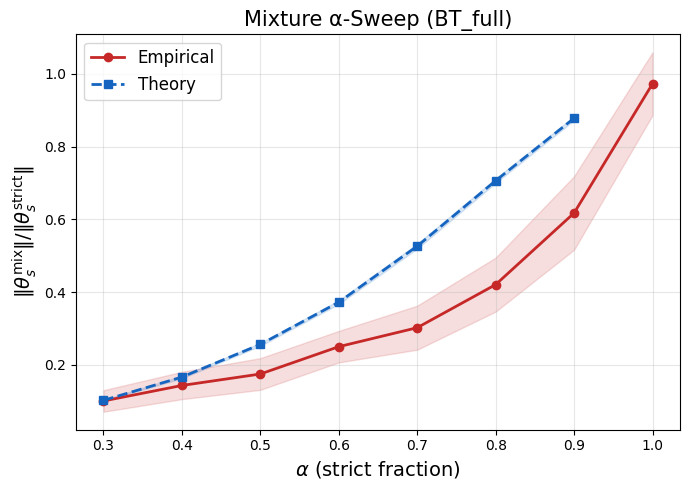


--- Level: BT_causal ---


sr=5.0, α=0.3:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.4:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.6:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.7:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.8:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.9:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=1.0:   0%|          | 0/10 [00:00<?, ?it/s]

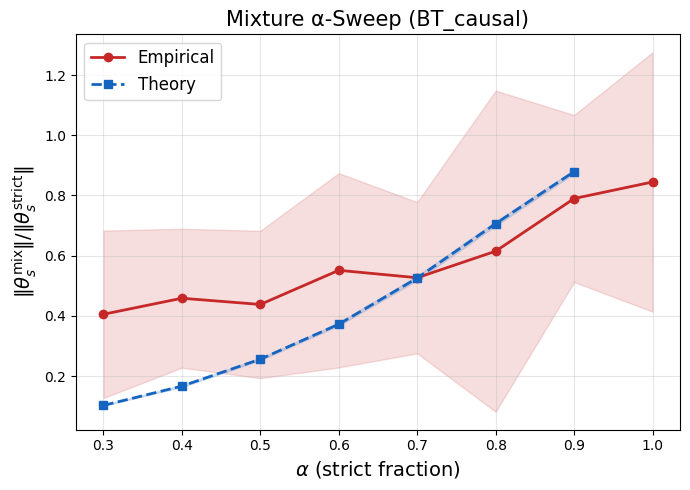


--- Level: no_BT ---


sr=5.0, α=0.3:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.4:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.6:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.7:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.8:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=0.9:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, α=1.0:   0%|          | 0/10 [00:00<?, ?it/s]

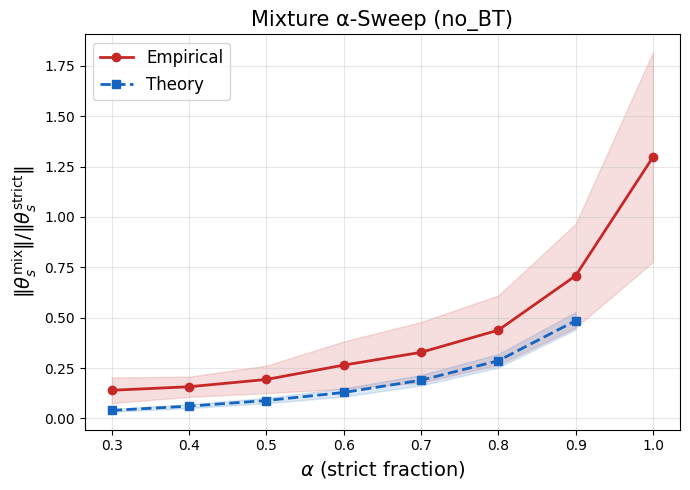


#################################################################
#  EXPERIMENT 2: Augmentation γ-sweep
#################################################################

--- Level: BT_full ---


sr=5.0, γ=0.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=1.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=2.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=3.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=5.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=10.0:   0%|          | 0/10 [00:00<?, ?it/s]

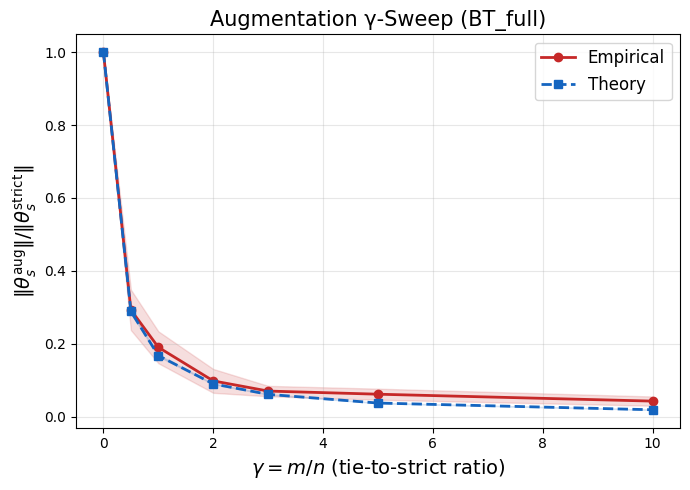


--- Level: BT_causal ---


sr=5.0, γ=0.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=1.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=2.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=3.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=5.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=10.0:   0%|          | 0/10 [00:00<?, ?it/s]

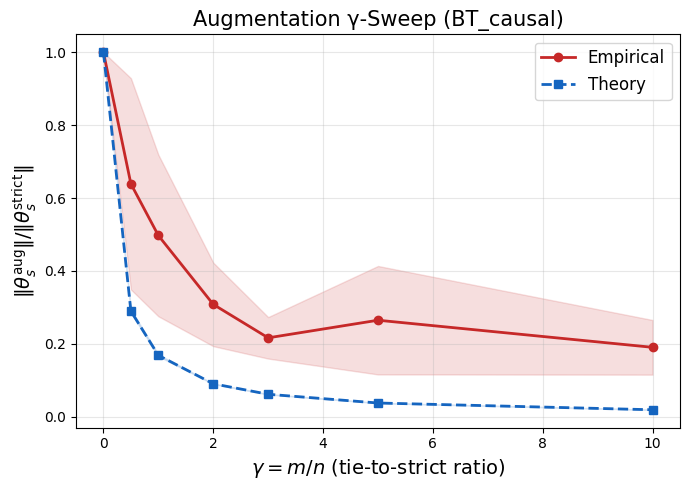


--- Level: no_BT ---


sr=5.0, γ=0.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=1.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=2.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=3.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=5.0:   0%|          | 0/10 [00:00<?, ?it/s]

sr=5.0, γ=10.0:   0%|          | 0/10 [00:00<?, ?it/s]

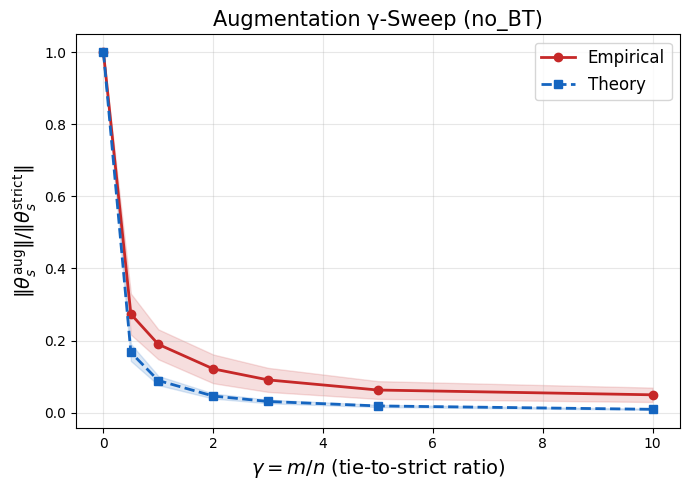


#################################################################
#  EXPERIMENT 3: Near-tie tolerance
#################################################################

--- Sweep: eta ---


eta=0.0:   0%|          | 0/10 [00:00<?, ?it/s]

eta=0.01:   0%|          | 0/10 [00:00<?, ?it/s]

eta=0.05:   0%|          | 0/10 [00:00<?, ?it/s]

eta=0.1:   0%|          | 0/10 [00:00<?, ?it/s]

eta=0.2:   0%|          | 0/10 [00:00<?, ?it/s]

eta=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

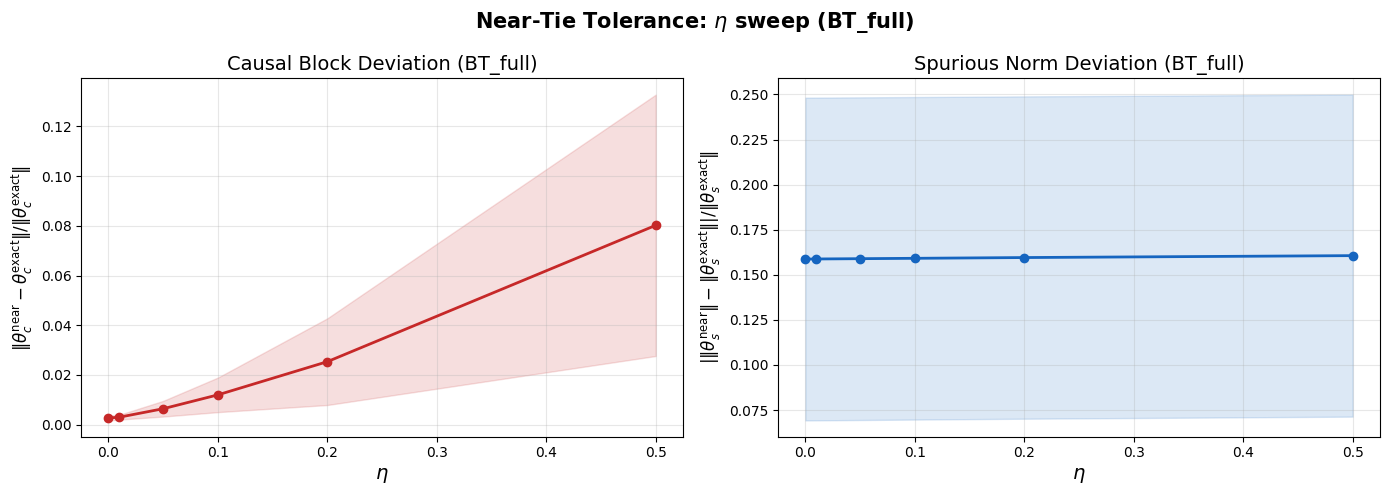


--- Sweep: tau_c2 ---


tau_c2=0.0:   0%|          | 0/10 [00:00<?, ?it/s]

tau_c2=0.01:   0%|          | 0/10 [00:00<?, ?it/s]

tau_c2=0.05:   0%|          | 0/10 [00:00<?, ?it/s]

tau_c2=0.1:   0%|          | 0/10 [00:00<?, ?it/s]

tau_c2=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

tau_c2=1.0:   0%|          | 0/10 [00:00<?, ?it/s]

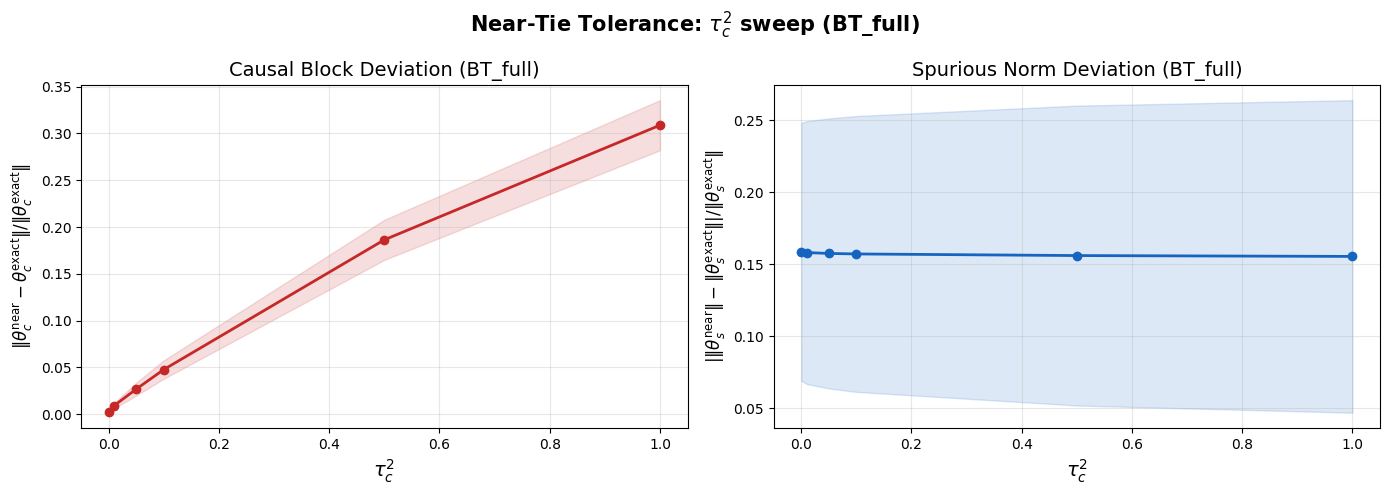


--- Sweep: kappa ---


kappa=0.0:   0%|          | 0/10 [00:00<?, ?it/s]

kappa=0.01:   0%|          | 0/10 [00:00<?, ?it/s]

kappa=0.05:   0%|          | 0/10 [00:00<?, ?it/s]

kappa=0.1:   0%|          | 0/10 [00:00<?, ?it/s]

kappa=0.2:   0%|          | 0/10 [00:00<?, ?it/s]

kappa=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

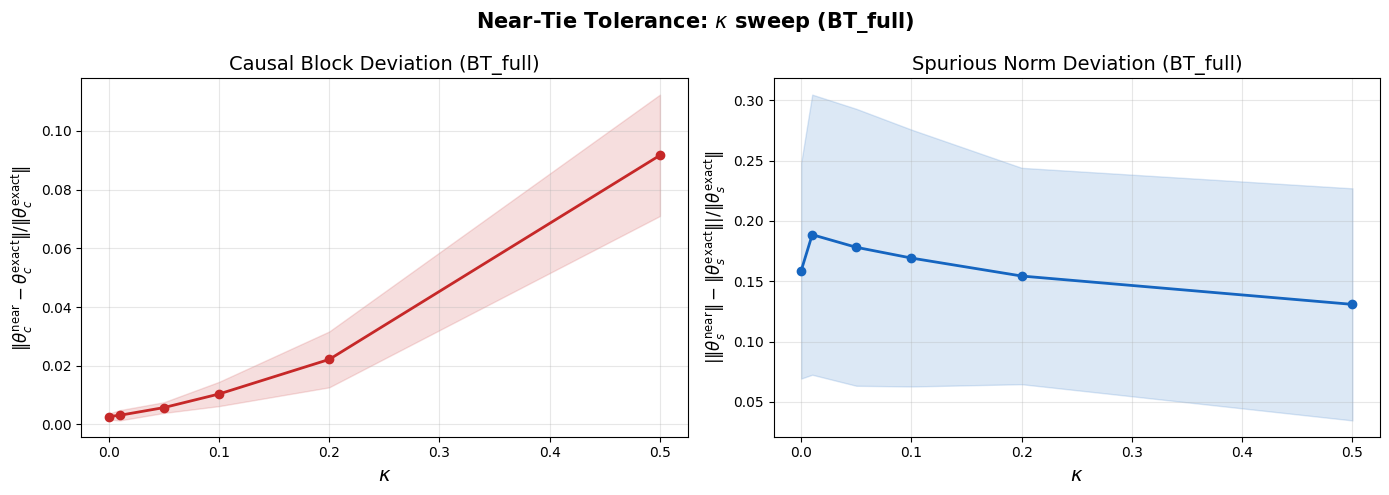


#################################################################
#  EXPERIMENT 4: Causal decontamination
#################################################################

--- Level: BT_full ---


α=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

α=0.6:   0%|          | 0/10 [00:00<?, ?it/s]

α=0.7:   0%|          | 0/10 [00:00<?, ?it/s]

α=0.8:   0%|          | 0/10 [00:00<?, ?it/s]

α=0.9:   0%|          | 0/10 [00:00<?, ?it/s]

α=1.0:   0%|          | 0/10 [00:00<?, ?it/s]

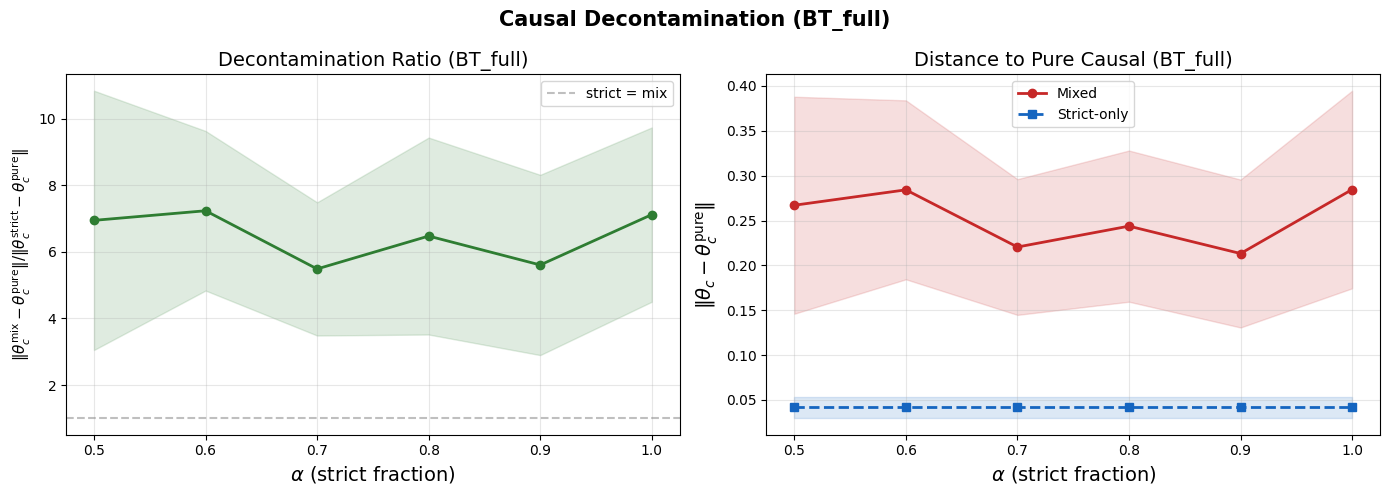


--- Level: BT_causal ---


α=0.5:   0%|          | 0/10 [00:00<?, ?it/s]

α=0.6:   0%|          | 0/10 [00:00<?, ?it/s]

α=0.7:   0%|          | 0/10 [00:00<?, ?it/s]

α=0.8:   0%|          | 0/10 [00:00<?, ?it/s]

α=0.9:   0%|          | 0/10 [00:00<?, ?it/s]

α=1.0:   0%|          | 0/10 [00:00<?, ?it/s]

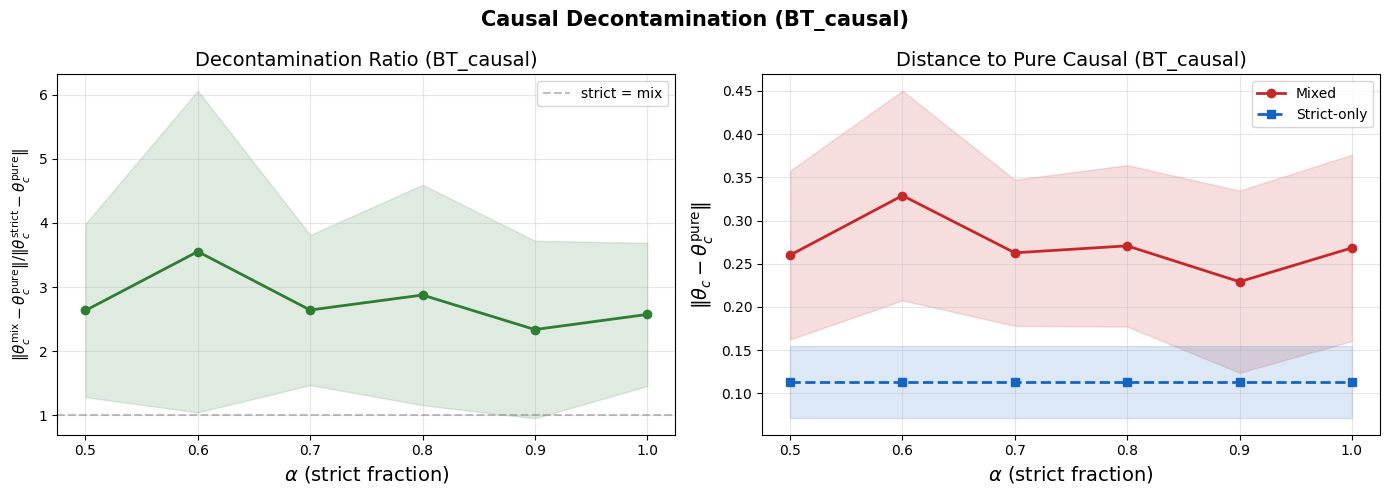

In [16]:
#@title MAIN

if __name__ == "__main__":

    # Shared config
    N = 8000
    d_c = 5
    d_s = 5
    beta = 0.3
    seeds = 10
    lam0 = 1.0

    # ==========================================
    # Experiment 1: Mixture α-sweep (all levels)
    # ==========================================
    print("\n" + "#"*65)
    print("#  EXPERIMENT 1: Mixture α-sweep")
    print("#"*65)

    for lvl in ["BT_full", "BT_causal", "no_BT"]:
        print(f"\n--- Level: {lvl} ---")
        df_mix = experiment_mixture_alpha_sweep(
            level=lvl, N=N, d_c=d_c, d_s=d_s, beta=beta,
            seeds=seeds, alphas=(0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
            sigma_ratios=[5.0], lam0=lam0,
            theta_scale=0.5, mu_scale=0.05, rho=0.5,
        )
        plot_mixture_alpha_sweep(df_mix, level=lvl)

    # ==================================
    # Experiment 2: Augmentation γ-sweep
    # ==================================
    print("\n" + "#"*65)
    print("#  EXPERIMENT 2: Augmentation γ-sweep")
    print("#"*65)

    for lvl in ["BT_full", "BT_causal", "no_BT"]:
        print(f"\n--- Level: {lvl} ---")
        df_aug = experiment_augmentation_gamma_sweep(
            level=lvl, n_strict=5000, d_c=d_c, d_s=d_s, beta=beta,
            seeds=seeds, gammas=(0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0),
            sigma_ratios=[5.0], lam0=lam0,
            theta_scale=0.5, mu_scale=0.05, rho=0.5,
        )
        plot_augmentation_gamma_sweep(df_aug, level=lvl)

    # =======================================
    # Experiment 3: Near-tie tolerance sweeps
    # =======================================
    print("\n" + "#"*65)
    print("#  EXPERIMENT 3: Near-tie tolerance")
    print("#"*65)

    for param in ["eta", "tau_c2", "kappa"]:
        print(f"\n--- Sweep: {param} ---")
        df_nt = experiment_near_tie_sweep(
            level="BT_full", N=N, d_c=d_c, d_s=d_s, beta=beta,
            seeds=seeds, alpha=0.7, sig2=5.0, lam0=lam0,
            theta_scale=0.5, sweep_param=param,
        )
        plot_near_tie_sweep(df_nt, sweep_param=param, level="BT_full")

    # ====================================
    # Experiment 4: Causal decontamination
    # ====================================
    print("\n" + "#"*65)
    print("#  EXPERIMENT 4: Causal decontamination")
    print("#"*65)

    for lvl in ["BT_full", "BT_causal"]:
        print(f"\n--- Level: {lvl} ---")
        df_decon = experiment_causal_decontamination(
            level=lvl, N=N, d_c=d_c, d_s=d_s, beta=beta,
            seeds=seeds, alphas=(0.5, 0.6, 0.7, 0.8, 0.9, 1.0),
            sig2=5.0, lam0=lam0, theta_scale=0.5, rho=0.5,
        )
        plot_causal_decontamination(df_decon, level=lvl)